<a href="https://colab.research.google.com/github/jss265/595R---Deep-Learning-for-Engineers/blob/main/HW%206%20-%20Neural%20ODE%20with%20AE%20and%20physics%20loss/PINODE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Using device: cpu
Xtrain: (600, 11, 128), Xtest: (100, 21, 128), Xcol: (10000, 128), fcol: (10000, 128)
Model parameters: 67,076
Starting training...
Epoch     1/2000 | Loss: 2.613087 | Test MSE: 1.366735 | Time: 0.5s
Epoch    50/2000 | Loss: 0.112907 | Test MSE: 0.333650 | Time: 41.8s
Epoch   100/2000 | Loss: 0.078074 | Test MSE: 0.297485 | Time: 95.2s
Epoch   150/2000 | Loss: 0.051412 | Test MSE: 0.250111 | Time: 149.8s
Epoch   200/2000 | Loss: 0.029492 | Test MSE: 0.119507 | Time: 206.0s
Epoch   250/2000 | Loss: 0.021024 | Test MSE: 0.081362 | Time: 261.7s
Epoch   300/2000 | Loss: 0.015828 | Test MSE: 0.086519 | Time: 315.5s
Epoch   350/2000 | Loss: 0.019325 | Test MSE: 0.092337 | Time: 369.6s
Epoch   400/2000 | Loss: 0.017392 | Test MSE: 0.099197 | Time: 424.3s
Epoch   450/2000 | Loss: 0.014538 | Test MSE: 0.084528 | Time: 478.4s
Epoch   500/2000 | Loss: 0.014018 | Test MSE: 0.079988 | Time: 532.7s
Epoch   550/2000 | Loss: 0.010726 | Test MSE: 0.077168 | Time: 586.6s
Epoch   600/20

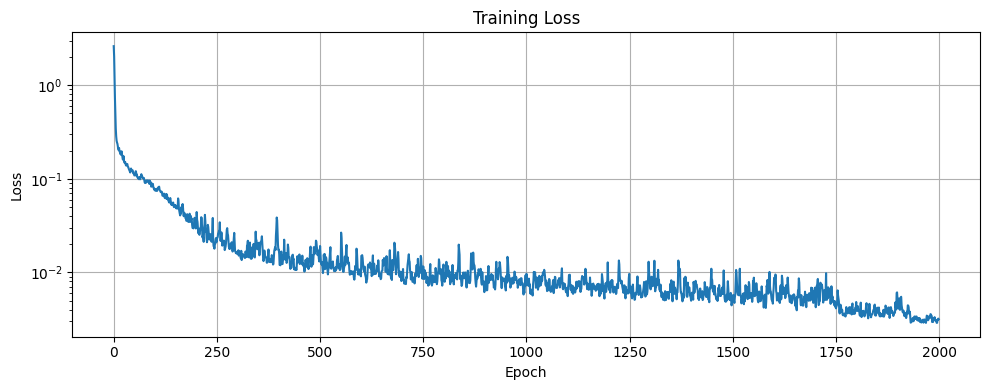

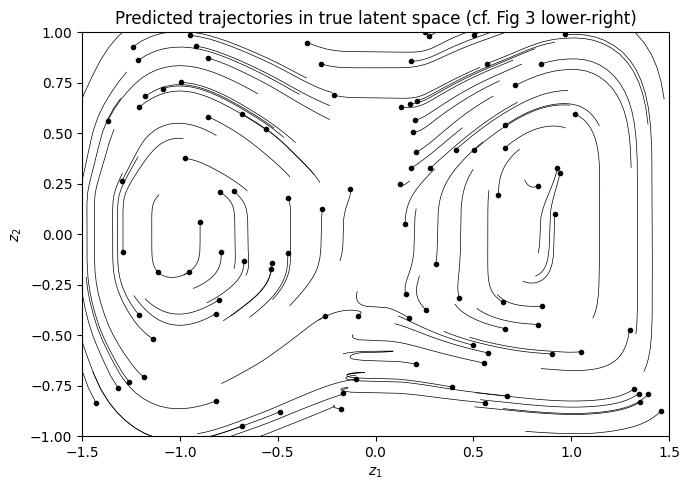

Done!


In [6]:
!pip install -q torchdiffeq

import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchdiffeq import odeint
import time

# Device & dtype setup
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")
DTYPE = torch.float64

# Provided data-generation code (unchanged)

def generatetrajectories(ntraj, tsteps, A, trainflag):
    nx, nz = A.shape
    nt = len(tsteps)
    if trainflag:
        z1 = np.random.uniform(low=-1.5, high=0.5, size=ntraj)
        z2 = np.random.uniform(low=-1, high=1, size=ntraj)
    else:
        z1 = np.random.uniform(low=-1.5, high=1.5, size=ntraj)
        z2 = np.random.uniform(low=-1, high=1, size=ntraj)
    Z0 = np.column_stack((z1, z2))
    Z = np.zeros((ntraj, nt, nz))
    def zode(t, z):
        return [z[1], z[0] - z[0]**3]
    for i in range(ntraj):
        sol = solve_ivp(zode, (tsteps[0], tsteps[-1]), Z0[i, :], t_eval=tsteps)
        Z[i, :, :] = sol.y.T
    X = np.zeros((ntraj, nt, nx))
    for i in range(nt):
        X[:, i, :] = Z[:, i, :]**3 @ A.T
    return X


def getdata(ntrain, ntest, ncol, t_train, t_test):
    nz = 2
    nx = 128
    A = np.random.normal(size=(nx, nz))
    Xtrain = generatetrajectories(ntrain, t_train, A, trainflag=True)
    Xtest = generatetrajectories(ntest, t_test, A, trainflag=False)
    z1 = np.random.uniform(low=0.5, high=1.5, size=ncol)
    z2 = np.random.uniform(low=-1, high=1, size=ncol)
    Zcol = np.column_stack((z1, z2))
    hZ = np.column_stack((Zcol[:, 1], Zcol[:, 0] - Zcol[:, 0]**3))
    fcol = np.zeros((ncol, nx))
    for i in range(ncol):
        fcol[i, :] = hZ[[i], :] @ (3 * A * Zcol[i, :].T**2).T
    Xcol = Zcol**3 @ A.T
    return Xtrain, Xtest, Xcol, fcol, A


def true_encoder(X, A):
    Z3 = X @ np.linalg.pinv(A).T
    return np.sign(Z3) * np.abs(Z3)**(1/3)


# Generate data
np.random.seed(42)

nt_train = 11
nt_test = 21
t_train = np.linspace(0.0, 1.0, nt_train)
t_test = np.linspace(0.0, 1.0, nt_test)

ntrain = 600
ntest = 100
ncol = 10000

Xtrain, Xtest, Xcol, fcol, Amap = getdata(ntrain, ntest, ncol, t_train, t_test)
print(f"Xtrain: {Xtrain.shape}, Xtest: {Xtest.shape}, Xcol: {Xcol.shape}, fcol: {fcol.shape}")

# Convert to torch tensors on device
Xtrain_t = torch.tensor(Xtrain, dtype=DTYPE, device=device)   # (ntrain, nt_train, 128)
Xtest_t  = torch.tensor(Xtest,  dtype=DTYPE, device=device)   # (ntest, nt_test, 128)
Xcol_t   = torch.tensor(Xcol,   dtype=DTYPE, device=device)   # (ncol, 128)
fcol_t   = torch.tensor(fcol,   dtype=DTYPE, device=device)   # (ncol, 128)
t_train_t = torch.tensor(t_train, dtype=DTYPE, device=device)  # (nt_train,)
t_test_t  = torch.tensor(t_test,  dtype=DTYPE, device=device)  # (nt_test,)

nx = 128
nz = 2  # latent dimension (we know the true manifold is 2D)

# Define neural network modules
# Architecture follows the paper's supplementary (Appendix A.1):
#   Encoder: nx -> 128 -> 64 -> nz          (with ELU activations)
#   Decoder: nz -> 64 -> 128 -> nx           (with ELU activations)
#   LatentODE: nz -> 128 -> 128 -> nz        (with ELU activations)

class Encoder(nn.Module):
    """Maps from observable space x (dim nx) to latent space z (dim nz)."""
    def __init__(self, nx, nz):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nx, 128),
            nn.ELU(),
            nn.Linear(128, 64),
            nn.ELU(),
            nn.Linear(64, nz),
        )

    def forward(self, x):
        return self.net(x)


class Decoder(nn.Module):
    """Maps from latent space z (dim nz) back to observable space x (dim nx)."""
    def __init__(self, nz, nx):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nz, 64),
            nn.ELU(),
            nn.Linear(64, 128),
            nn.ELU(),
            nn.Linear(128, nx),
        )

    def forward(self, z):
        return self.net(z)


class LatentODE(nn.Module):
    """The right-hand side g_theta(z) of the ODE dz/dt = g_theta(z) in latent space."""
    def __init__(self, nz):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(nz, 128),
            nn.ELU(),
            nn.Linear(128, 128),
            nn.ELU(),
            nn.Linear(128, nz),
        )

    def forward(self, t, z):
        return self.net(z)


class PINODE(nn.Module):
    """Full model: Encoder + LatentODE + Decoder."""
    def __init__(self, nx, nz):
        super().__init__()
        self.encoder = Encoder(nx, nz)
        self.decoder = Decoder(nz, nx)
        self.latent_ode = LatentODE(nz)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward_trajectory(self, x0, t_eval):
        """
        Given initial conditions x0 (batch, nx) and time points t_eval (nt,),
        returns predicted trajectory in observable space (batch, nt, nx).
        """
        z0 = self.encoder(x0)                          # (batch, nz)
        # odeint expects z0 of shape (batch, nz), returns (nt, batch, nz)
        z_traj = odeint(self.latent_ode, z0, t_eval)   # (nt, batch, nz)
        # permute to (batch, nt, nz) — NOT reshape!
        z_traj = z_traj.permute(1, 0, 2)               # (batch, nt, nz)
        # decode every snapshot
        batch, nt, _ = z_traj.shape
        x_pred = self.decoder(z_traj.reshape(batch * nt, -1))  # (batch*nt, nx)
        x_pred = x_pred.reshape(batch, nt, -1)                 # (batch, nt, nx)
        return x_pred

    def physics_loss(self, x_col, f_col):
        """
        Collocation-based physics loss (Eq. 9 in the paper).

        For each collocation point x_col, we need:
            g_theta(enc(x_col)) = (d enc / d x) @ f(x_col)

        where f(x_col) = f_col is the known dynamics evaluated at x_col.

        We compute d enc / d x via two calls to autograd.grad (one per latent dim),
        then multiply by f_col.
        """
        x = x_col.detach().requires_grad_(True)  # (N, nx)
        z = self.encoder(x)                       # (N, nz)

        N = x.shape[0]

        # dz_i/dx for each latent dimension i
        # z[:, 0] -> grad w.r.t. x gives (N, nx)
        dz0_dx = torch.autograd.grad(
            outputs=z[:, 0], inputs=x,
            grad_outputs=torch.ones(N, dtype=DTYPE, device=x.device),
            create_graph=True
        )[0]  # (N, nx)

        dz1_dx = torch.autograd.grad(
            outputs=z[:, 1], inputs=x,
            grad_outputs=torch.ones(N, dtype=DTYPE, device=x.device),
            create_graph=True
        )[0]  # (N, nx)

        # Stack into Jacobian: (N, nz, nx)
        Jac = torch.stack([dz0_dx, dz1_dx], dim=1)  # (N, nz, nx)

        # RHS of physics constraint: Jac @ f_col
        # f_col is (N, nx), unsqueeze to (N, nx, 1) for bmm
        rhs = torch.bmm(Jac, f_col.unsqueeze(2)).squeeze(2)  # (N, nz)

        # LHS: g_theta(enc(x_col))
        lhs = self.latent_ode(None, z)  # (N, nz)

        # MSE between lhs and rhs
        loss = torch.mean((lhs - rhs)**2)
        return loss


# Instantiate model
torch.manual_seed(42)
model = PINODE(nx, nz).to(DTYPE).to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

# Training loop
# Hyperparameters
num_epochs = 2000
lr = 1e-3
nbatches = 10  # number of mini-batches per epoch

# Loss weights (paper sets alpha_1 = alpha_2 = 1,
# and balances by making collocation batch size = trajectory batch size * T)
w_pred = 1.0    # prediction loss weight
w_recon = 1.0   # reconstruction loss weight
w_phys = 1.0    # physics loss weight

batch_size_train = int(ntrain / nbatches)
batch_size_col   = int(ncol / nbatches)

# DataLoaders
train_dataset = TensorDataset(Xtrain_t)
col_dataset   = TensorDataset(Xcol_t, fcol_t)

train_loader = DataLoader(train_dataset, batch_size=batch_size_train, shuffle=True)
col_loader   = DataLoader(col_dataset,   batch_size=batch_size_col,   shuffle=True)

optimizer = optim.Adam(model.parameters(), lr=lr)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=100, factor=0.5)

loss_history = []
test_mse_history = []

print("Starting training...")
t_start = time.time()

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    col_iter = iter(col_loader)

    for (Xbatch,) in train_loader:
        # Get matching collocation batch
        try:
            Xcol_batch, fcol_batch = next(col_iter)
        except StopIteration:
            col_iter = iter(col_loader)
            Xcol_batch, fcol_batch = next(col_iter)

        optimizer.zero_grad()

        # --- Prediction loss (Eq. 5): compare full trajectory ---
        # Xbatch is (B, nt_train, nx)
        x0 = Xbatch[:, 0, :]                                      # (B, nx)
        Xpred = model.forward_trajectory(x0, t_train_t)            # (B, nt_train, nx)
        loss_pred = torch.mean((Xpred - Xbatch)**2)

        # --- Reconstruction loss (Eq. 4): encode then decode ALL time steps ---
        B, nt, nxd = Xbatch.shape
        Xflat = Xbatch.reshape(B * nt, nxd)                       # (B*nt, nx)
        Zflat = model.encode(Xflat)                                # (B*nt, nz)
        Xrecon = model.decode(Zflat)                               # (B*nt, nx)
        loss_recon = torch.mean((Xrecon - Xflat)**2)

        # --- Physics / collocation loss (Eq. 9) ---
        loss_phys = model.physics_loss(Xcol_batch, fcol_batch)

        # --- Combined loss (Eq. 10) ---
        loss = w_pred * loss_pred + w_recon * loss_recon + w_phys * loss_phys

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    avg_loss = epoch_loss / nbatches
    loss_history.append(avg_loss)
    scheduler.step(avg_loss)

    # Evaluate test MSE every 50 epochs
    if (epoch + 1) % 50 == 0 or epoch == 0:
        model.eval()
        with torch.no_grad():
            x0_test = Xtest_t[:, 0, :]
            Xpred_test = model.forward_trajectory(x0_test, t_test_t)
            test_mse = torch.mean((Xpred_test - Xtest_t)**2).item()
            test_mse_history.append((epoch + 1, test_mse))
        elapsed = time.time() - t_start
        print(f"Epoch {epoch+1:5d}/{num_epochs} | Loss: {avg_loss:.6f} | "
              f"Test MSE: {test_mse:.6f} | Time: {elapsed:.1f}s")

print(f"\nTraining complete in {time.time()-t_start:.1f}s")

# Final test evaluation
model.eval()
with torch.no_grad():
    x0_test = Xtest_t[:, 0, :]
    Xhat_t = model.forward_trajectory(x0_test, t_test_t)  # (ntest, nt_test, nx)
    final_test_mse = torch.mean((Xhat_t - Xtest_t)**2).item()
    print(f"\n*** Final Test MSE: {final_test_mse:.6f} ***")
    print(f"*** Target: < 0.1 ***")

# Training loss plot
plt.figure(figsize=(10, 4))
plt.semilogy(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.tight_layout()
plt.show()

# Phase portrait plot (like Fig 3 lower-right)
Xhat_np = Xhat_t.cpu().numpy()  # (ntest, nt_test, nx)
Zhat = true_encoder(Xhat_np, Amap)

plt.figure(figsize=(7, 5))
for i in range(ntest):
    plt.plot(Zhat[i, 0, 0], Zhat[i, 0, 1], "ko", markersize=3)
    plt.plot(Zhat[i, :, 0], Zhat[i, :, 1], "k", linewidth=0.5)
plt.xlim([-1.5, 1.5])
plt.ylim([-1, 1])
plt.xlabel("$z_1$")
plt.ylabel("$z_2$")
plt.title("Predicted trajectories in true latent space (cf. Fig 3 lower-right)")
plt.tight_layout()
plt.show()

print("Done!")